# Aerial Image Preprocessing for multi temporal data for Iceland - 1996

Here we process the 1996 dataset with fiducial markers (all are correctly detected)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import hipp
import pandas as pd
from pathlib import Path

### Downloading files from FTP

In [4]:
# !mkdir -p /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1996_07_27_aux/raw_images
# !wget -np -A tif -r https://ftp.lmi.is/.stm/joaquin/myr/1996/ -nd -nc -P /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1996_07_27_aux/raw_images

# !mkdir -p /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1986_07_17_aux/raw_images
# !wget -np -A tif -r https://ftp.lmi.is/.stm/joaquin/myr/1986/ -nd -nc -P /mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1986_07_17_aux/raw_images

### Setup subfolders and configuration

In [ ]:
project_dir = Path("/mnt/summer/USERS/DEHECQA/history/data_prep/iceland/aerial_images/1996_07_27_aux")

paths: dict[str, Path] = {}
paths["raw_images"] = project_dir / "raw_images"
paths["preproc_images"] = project_dir / "preprocessed_images"
paths["crop_images"] = project_dir / "cropped_images"
paths["fiducial_templates"] = project_dir / "fiducial_templates"
paths["qc"] = project_dir / "qc"
paths["detected_fiducials"] = paths["raw_images"] / "detected_fiducial_markers.csv"
paths["tf_detected_fiducials"] = paths["preproc_images"] / "detected_fiducial_markers.csv"
paths["crop_detected_fiducials"] = paths["crop_images"] / "detected_fiducial_markers.csv"
paths["intrinsics"] = project_dir / "camera_model_intrinsics.csv"
paths["extrinsics"] = project_dir / "camera_model_extrinsics.csv"
paths["footprint"] = project_dir / "images_footprint.geojson"
paths["dir"] = project_dir

project_dir.mkdir(parents=True, exist_ok=True)

MAX_WORKERS = 4
QUICKVIEW_FACTOR = 0.2
OVERWRITE = False

In [6]:
hipp.tools.generate_quickviews(paths["raw_images"], QUICKVIEW_FACTOR, max_workers=MAX_WORKERS, overwrite=OVERWRITE)

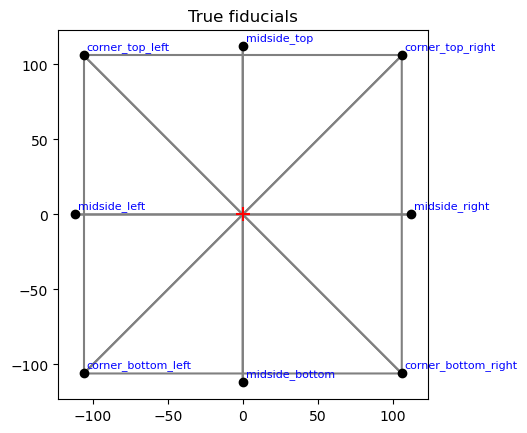

In [7]:
focal_length = 153.15
pixel_pitch = 0.015

fiducial_coords = [
    (105.997, -105.997),
    (-106.001, -106.001),
    (-106.001, 106.000),
    (105.999, 106.000),
    (-0.002, -112.001),
    (-111.998, 0.003),
    (-0.001, 112.000),
    (111.995, 0.002),
    (0.006, -0.009) # ppa
]
intrinsics = hipp.Intrinsics.from_list(focal_length, pixel_pitch, fiducial_coords)
intrinsics.to_csv(paths["intrinsics"])
hipp.aerial.qc.plot_true_fiducials(intrinsics.true_fiducials_mm)

### On first time, click on the interactive plot to identify the marker

Since the 4 markers of each type (corner or midside) are slightly different - they are numbered 1-4 with dots - picking the lower right and bottom ones, which have fewer dots and clearly visible in the first image. 

In [8]:
# first_image_path = sorted(paths["raw_images"].glob("*.tif"))[0]
# corner_marker_coords = hipp.aerial.create_fiducial_templates(first_image_path, paths["fiducial_templates"], corner=True, distance_around_fiducial=75)
# midside_marker_coords = hipp.aerial.create_fiducial_templates(first_image_path, paths["fiducial_templates"], midside=True, distance_around_fiducial=85)

### For reproducibility, save the markers template location for next runs

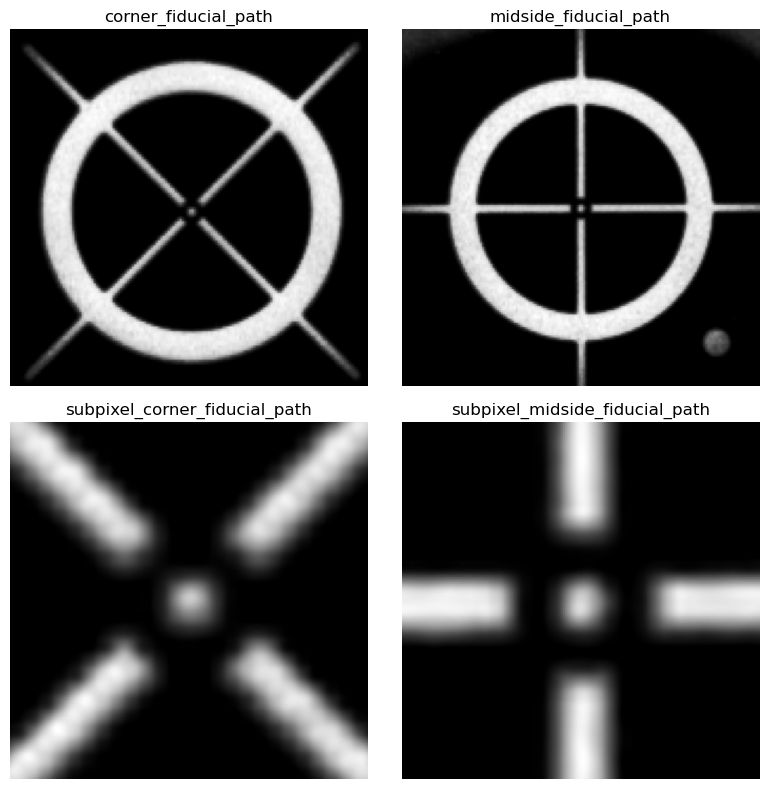

In [9]:
first_image_path = sorted(paths["raw_images"].glob("*.tif"))[0]

saved_coords_corner = {'fiducial_coordinate': (16131, 15015), 'subpixel_center_coordinate': (608, 615)}
saved_coords_midside = {'fiducial_coordinate': (9068, 15438), 'subpixel_center_coordinate': (679, 683)}

_ = hipp.aerial.create_fiducial_templates(first_image_path, paths["fiducial_templates"], corner=True, distance_around_fiducial=75, **saved_coords_corner)
_ = hipp.aerial.create_fiducial_templates(first_image_path, paths["fiducial_templates"], midside=True, distance_around_fiducial=85, **saved_coords_midside) 
hipp.aerial.qc.plot_fiducial_templates(paths["fiducial_templates"])

Fiducial detections: 100%|██████████| 88/88 [00:49<00:00,  1.78Image/s]


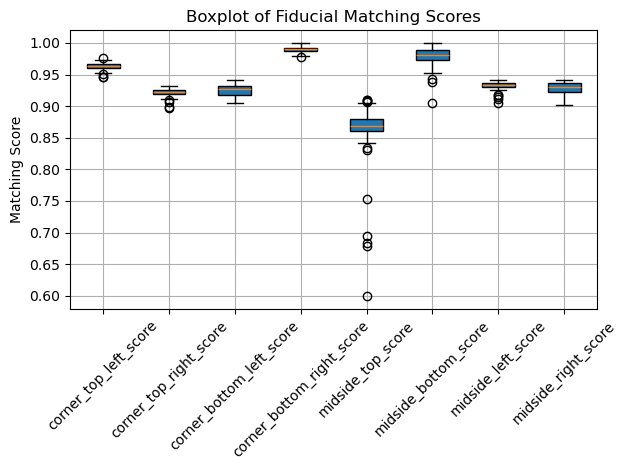

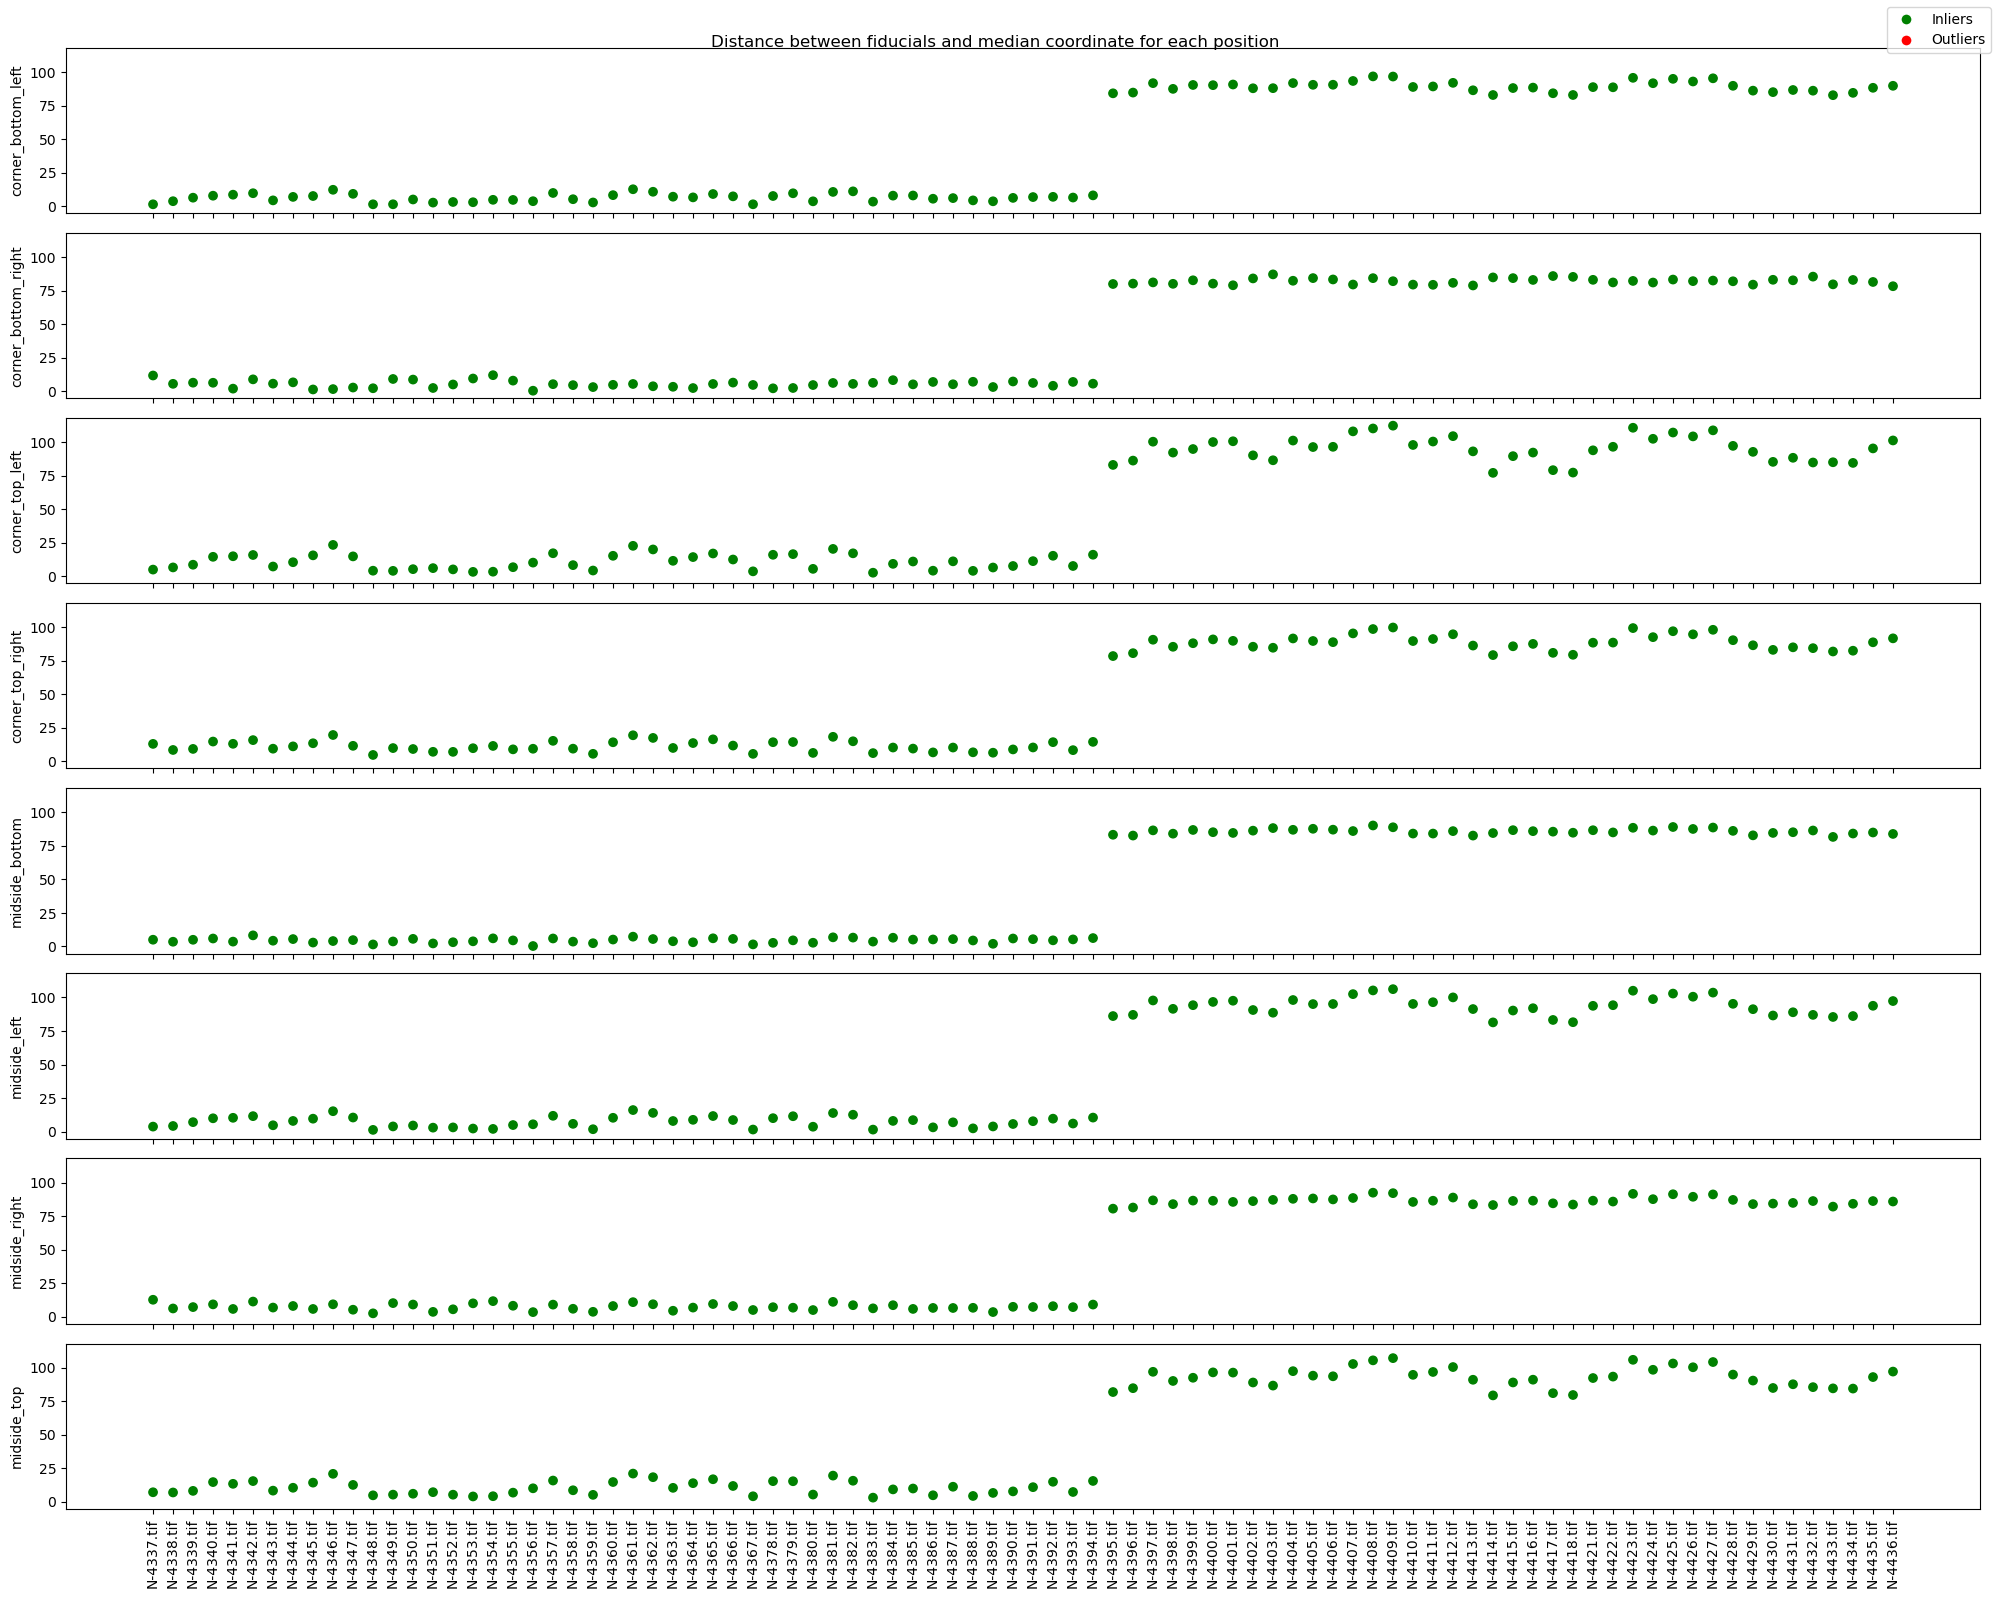

In [11]:
detected_fiducials_df = hipp.aerial.iter_detect_fiducials(paths["raw_images"], paths["fiducial_templates"], grid_size=7, max_workers=MAX_WORKERS)

# filter detection and save them into a csv
filtered_detected_fiducials_df = hipp.aerial.filter_detected_fiducials(detected_fiducials_df)
filtered_detected_fiducials_df.round(2).to_csv(paths["detected_fiducials"])

# plot matching score
output_plot_path = paths["qc"] / "detection_score_boxplot.png"
hipp.aerial.qc.plot_detection_score_boxplot(detected_fiducials_df, show=True, output_plot_path=output_plot_path)

# plot fiducials filtering
output_plot_path = paths["qc"] / "fiducials_filtering.png"
hipp.aerial.qc.plot_fiducials_filtering(detected_fiducials_df,filtered_detected_fiducials_df, show=True, output_plot_path=output_plot_path)

# plot individuals detection
output_dir = paths["qc"] / "individual_detections"
hipp.aerial.qc.generate_detection_qc_plots(paths["raw_images"], detected_fiducials_df, output_dir)


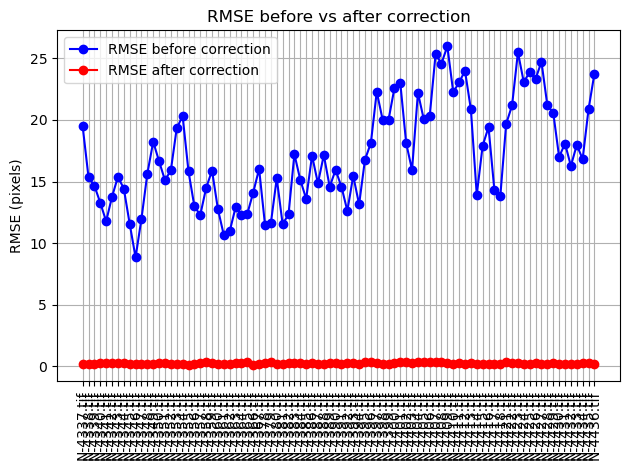

Generating quickviews: 100%|██████████| 88/88 [11:42<00:00,  7.99s/image]


In [17]:
intrinsics = hipp.Intrinsics.from_csv(paths["intrinsics"])
image_square_dim = int(228.6 / intrinsics.pixel_pitch) - 5 

fiducials_df = pd.read_csv(paths["detected_fiducials"], index_col="image_id")

transformations = hipp.aerial.compute_transformations(fiducials_df, intrinsics.true_fiducials_mm, image_square_dim, intrinsics.pixel_pitch)

# save the transformed detected fiducial markers (coordinate of fiducials in preprocessed images)
paths["tf_detected_fiducials"].parent.mkdir(parents=True, exist_ok=True)
hipp.aerial.warp_fiducials_df(fiducials_df, transformations).round(2).to_csv(paths["tf_detected_fiducials"])

# plot the correction to ensure it's correct
hipp.aerial.qc.plot_fiducials_correction(fiducials_df, transformations, intrinsics.true_fiducials_mm, intrinsics.pixel_pitch)

# Image warping
hipp.aerial.iter_image_restitution(
    paths["raw_images"], 
    paths["preproc_images"], 
    transformations,
    image_square_dim=image_square_dim,
    max_workers=MAX_WORKERS,
    overwrite=OVERWRITE
)
hipp.tools.generate_quickviews(paths["preproc_images"], factor=QUICKVIEW_FACTOR, max_workers=MAX_WORKERS, overwrite=OVERWRITE)